# Projeto G2 — Análise de Redes Sociais no Brasil

## Disciplina: Linguagem de Programação — Análise e Visualização de Dados com Python
## Aluno: Nathan Silva Cardoso


Este notebook apresenta uma análise exploratória da base `simulacao_redes_sociais_brasil.csv`, com foco em desempenho de plataformas, engajamento, alcance e tipos de conteúdo.


# 1. Problema de negócio

### Pergunta principal

Quais fatores estão mais associados ao sucesso de uma publicação nas redes sociais?

### Perguntas secundárias

- Qual plataforma gera maior alcance?
- Qual plataforma gera mais engajamento?
- Quais tipos de conteúdo performam melhor?
- Existe evolução temporal nos resultados?
- Existem horários mais favoráveis para publicação?

### Possíveis decisões

- Direcionar investimento para plataformas mais eficientes.
- Priorizar formatos de conteúdo com maior engajamento.
- Ajustar calendário de publicações.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)



# 2. Leitura da base de dados

In [5]:
df = pd.read_csv('simulacao_redes_sociais_brasil.csv')

print('Dimensões:', df.shape)
df.head()


Dimensões: (4440, 15)


,ano,mes,data,plataforma,perfil,categoria,tipo_conteudo,seguidores,curtidas,comentarios,compartilhamentos,visualizacoes,alcance,taxa_engajamento,horario_publicacao
0,2015,1,2015-01-01,LinkedIn,EducaOnline,Entretenimento,Vídeo,608562,60519,4204,8462,46688,601986,3.31,08:00
1,2015,1,2015-01-01,TikTok,GamesBR,Tecnologia,Imagem,733755,77926,199,7096,1635721,1798994,7.68,08:00
2,2015,1,2015-01-01,LinkedIn,GamesBR,Educação,Stories,986048,48692,4437,2047,1799255,2354880,4.79,18:00
3,2015,1,2015-01-01,YouTube,ModaHoje,Games,Imagem,814782,49169,3738,1740,195735,2072736,3.26,12:00
4,2015,1,2015-01-01,Facebook,TechBrasil,Tecnologia,Live,270513,585,2480,7029,1096820,2457502,3.48,21:00


# 3. Check-up inicial da base

In [6]:
print('Dimensões:', df.shape)
print('\nTipos de dados:')
print(df.dtypes)
print('\nValores ausentes:')
print(df.isnull().sum())

Dimensões: (4440, 15)

Tipos de dados:
ano                     int64
mes                     int64
data                   object
plataforma             object
perfil                 object
categoria              object
tipo_conteudo          object
seguidores              int64
curtidas                int64
comentarios             int64
compartilhamentos       int64
visualizacoes           int64
alcance                 int64
taxa_engajamento      float64
horario_publicacao     object
dtype: object

Valores ausentes:
ano                   0
mes                   0
data                  0
plataforma            0
perfil                0
categoria             0
tipo_conteudo         0
seguidores            0
curtidas              0
comentarios           0
compartilhamentos     0
visualizacoes         0
alcance               0
taxa_engajamento      0
horario_publicacao    0
dtype: int64


# 4. Preparação dos dados

Nesta etapa serão tratados valores ausentes, conversões de tipos e criação de variáveis derivadas.


In [7]:
# Ajustes automáticos quando as colunas existirem

if 'data' in df.columns:
    df['data'] = pd.to_datetime(df['data'])
    df['ano'] = df['data'].dt.year
    df['mes'] = df['data'].dt.month

if {'curtidas','comentarios','compartilhamentos'}.issubset(df.columns):
    df['interacoes'] = (
        df['curtidas']
        + df['comentarios']
        + df['compartilhamentos']
    )

df.head()


,ano,mes,data,plataforma,perfil,categoria,tipo_conteudo,seguidores,curtidas,comentarios,compartilhamentos,visualizacoes,alcance,taxa_engajamento,horario_publicacao,interacoes
0,2015,1,2015-01-01,LinkedIn,EducaOnline,Entretenimento,Vídeo,608562,60519,4204,8462,46688,601986,3.31,08:00,73185
1,2015,1,2015-01-01,TikTok,GamesBR,Tecnologia,Imagem,733755,77926,199,7096,1635721,1798994,7.68,08:00,85221
2,2015,1,2015-01-01,LinkedIn,GamesBR,Educação,Stories,986048,48692,4437,2047,1799255,2354880,4.79,18:00,55176
3,2015,1,2015-01-01,YouTube,ModaHoje,Games,Imagem,814782,49169,3738,1740,195735,2072736,3.26,12:00,54647
4,2015,1,2015-01-01,Facebook,TechBrasil,Tecnologia,Live,270513,585,2480,7029,1096820,2457502,3.48,21:00,10094


# 5. Definição dos KPIs

### KPI 1 - Alcance Total
Soma do alcance das publicações.

### KPI 2 - Interações Totais
Soma de curtidas, comentários e compartilhamentos.

### KPI 3 - Taxa Média de Engajamento
Média da taxa de engajamento registrada.

### KPI 4 - Visualizações Totais
Total de visualizações obtidas.


In [8]:
kpis = {}

if 'alcance' in df.columns:
    kpis['Alcance Total'] = df['alcance'].sum()

if 'interacoes' in df.columns:
    kpis['Interações Totais'] = df['interacoes'].sum()

if 'taxa_engajamento' in df.columns:
    kpis['Engajamento Médio'] = round(df['taxa_engajamento'].mean(),2)

if 'visualizacoes' in df.columns:
    kpis['Visualizações Totais'] = df['visualizacoes'].sum()

pd.DataFrame(kpis.items(), columns=['KPI','Valor'])


,KPI,Valor
0,Alcance Total,5.605076e+09
1,Interações Totais,2.112369e+08
2,Engajamento Médio,6.240000e+00
3,Visualizações Totais,4.474794e+09


# 6. Análise Exploratória dos Dados

In [9]:
# Estatísticas numéricas
df.describe()


,ano,mes,data,seguidores,curtidas,comentarios,compartilhamentos,visualizacoes,alcance,taxa_engajamento,interacoes
count,4440.000000,4440.000000,4440,4440.000000,4440.000000,4440.000000,4440.000000,4.440000e+03,4.440000e+03,4440.000000,4440.000000
mean,2019.500000,6.500000,2019-12-16 10:48:00,500083.756757,40093.574775,2489.472072,4992.835586,1.007836e+06,1.262404e+06,6.235232,47575.882432
min,2015.000000,1.000000,2015-01-01 00:00:00,1345.000000,170.000000,10.000000,10.000000,2.554000e+03,1.853000e+03,0.500000,2454.000000
25%,2017.000000,3.750000,2017-06-23 12:00:00,253730.000000,20187.000000,1230.500000,2516.750000,5.188282e+05,6.401402e+05,3.320000,27633.000000
50%,2019.500000,6.500000,2019-12-16 12:00:00,502211.500000,39959.000000,2496.500000,4980.000000,1.016972e+06,1.275360e+06,6.220000,47614.000000
75%,2022.000000,9.250000,2022-06-08 12:00:00,743244.750000,59847.500000,3769.750000,7459.500000,1.502863e+06,1.883703e+06,9.090000,67276.500000
max,2024.000000,12.000000,2024-12-01 00:00:00,999977.000000,79983.000000,4998.000000,9998.000000,1.998805e+06,2.499265e+06,12.000000,93401.000000
std,2.872605,3.452441,NaN,284372.590139,22879.700467,1446.163371,2876.100655,5.730440e+05,7.185064e+05,3.344578,23092.937250


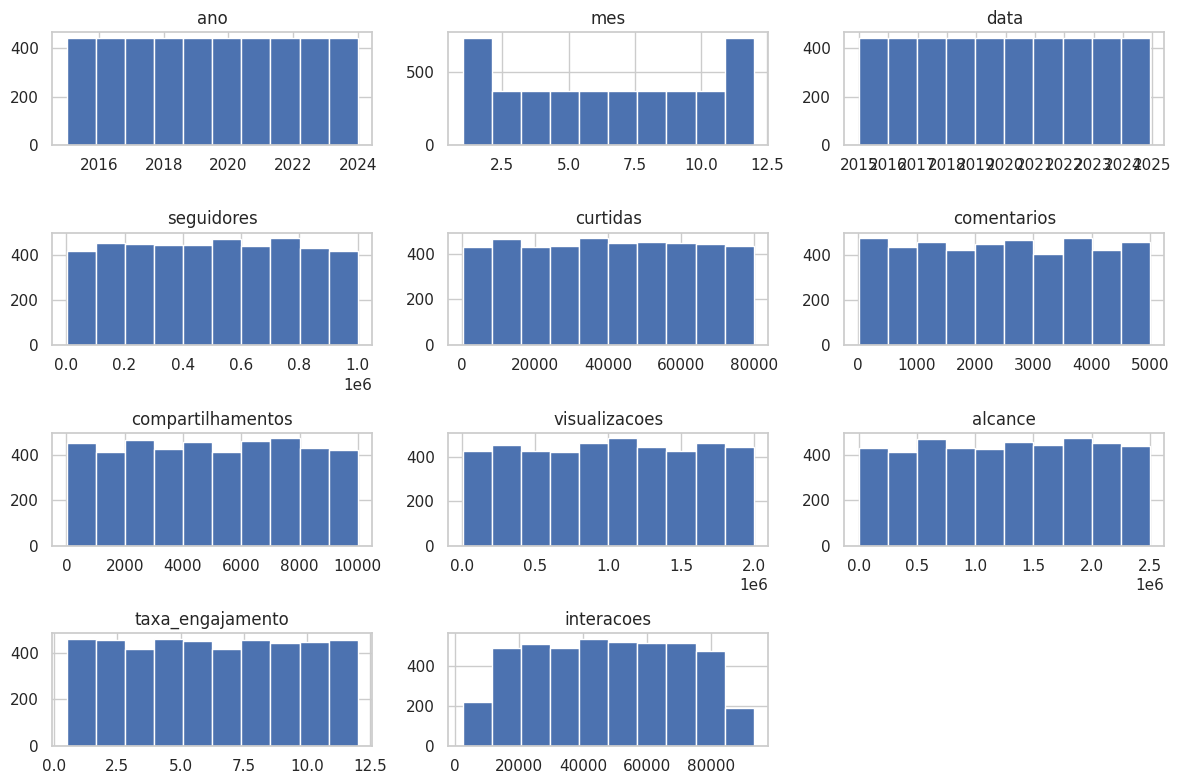

In [10]:
# Distribuição das variáveis numéricas
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()


# 7. Comparações por Plataforma

In [11]:
if {'plataforma','alcance'}.issubset(df.columns):
    plataforma_alcance = (
        df.groupby('plataforma')['alcance']
        .sum()
        .sort_values(ascending=False)
    )
    display(plataforma_alcance)


,alcance
plataforma,
LinkedIn,942026620
TikTok,936259007
X,935782269
Instagram,932289803
Facebook,929404782
YouTube,929313142


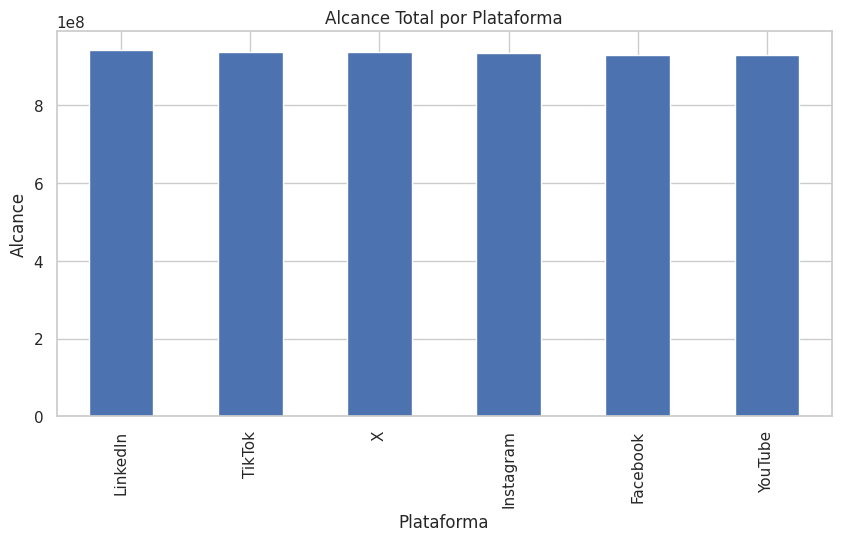

In [12]:
if {'plataforma','alcance'}.issubset(df.columns):
    plataforma_alcance.plot(kind='bar')
    plt.title('Alcance Total por Plataforma')
    plt.xlabel('Plataforma')
    plt.ylabel('Alcance')
    plt.show()


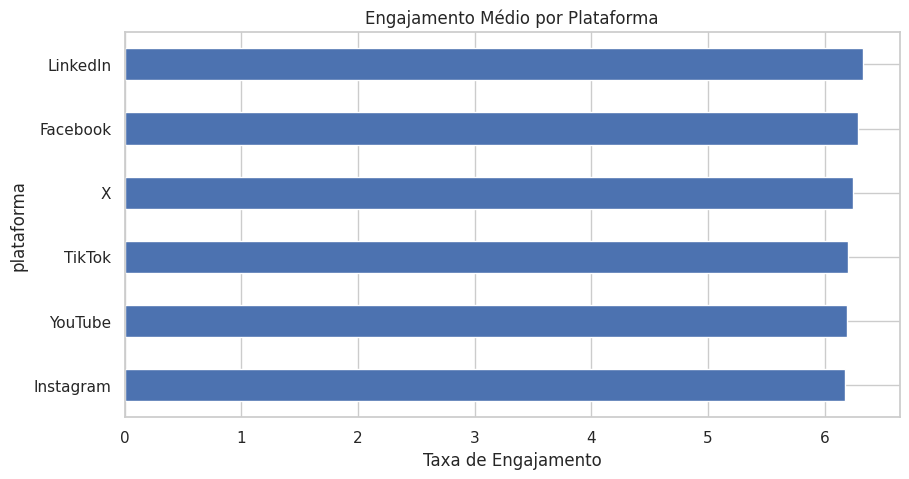

In [13]:
if {'plataforma','taxa_engajamento'}.issubset(df.columns):
    df.groupby('plataforma')['taxa_engajamento'].mean().sort_values().plot(kind='barh')
    plt.title('Engajamento Médio por Plataforma')
    plt.xlabel('Taxa de Engajamento')
    plt.show()


# 8. Comparações por Tipo de Conteúdo

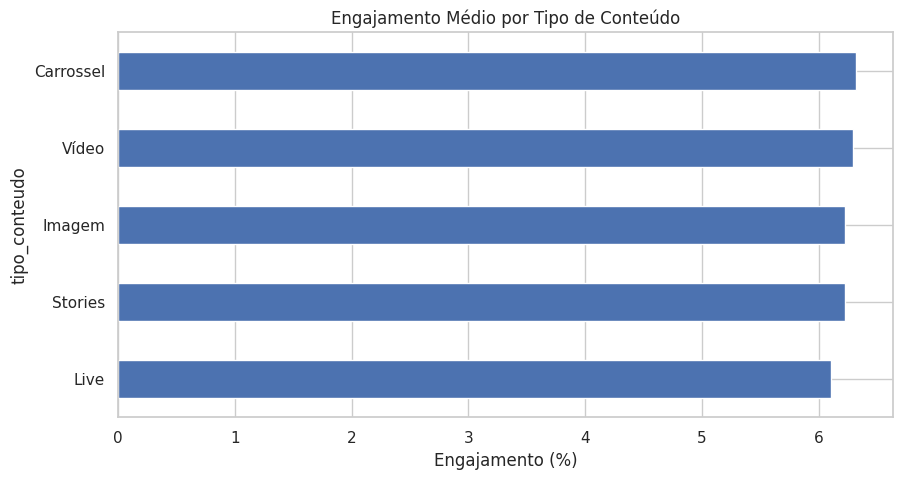

In [14]:
if {'tipo_conteudo','taxa_engajamento'}.issubset(df.columns):
    df.groupby('tipo_conteudo')['taxa_engajamento'].mean().sort_values().plot(kind='barh')
    plt.title('Engajamento Médio por Tipo de Conteúdo')
    plt.xlabel('Engajamento (%)')
    plt.show()


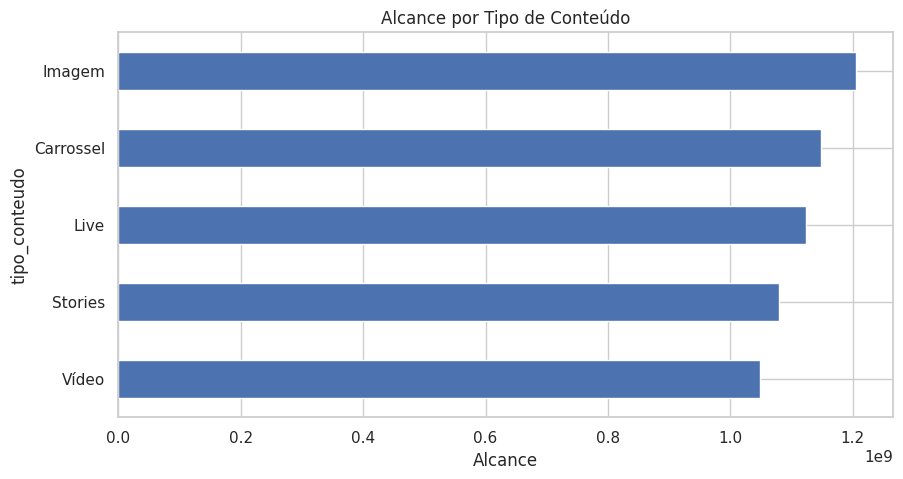

In [15]:
if {'tipo_conteudo','alcance'}.issubset(df.columns):
    df.groupby('tipo_conteudo')['alcance'].sum().sort_values().plot(kind='barh')
    plt.title('Alcance por Tipo de Conteúdo')
    plt.xlabel('Alcance')
    plt.show()


# 9. Evolução Temporal

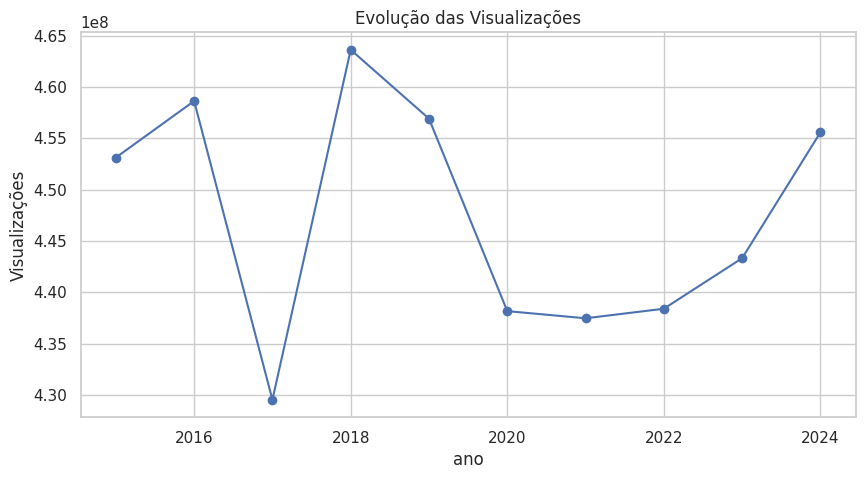

In [16]:
if {'ano','visualizacoes'}.issubset(df.columns):
    df.groupby('ano')['visualizacoes'].sum().plot(marker='o')
    plt.title('Evolução das Visualizações')
    plt.ylabel('Visualizações')
    plt.show()


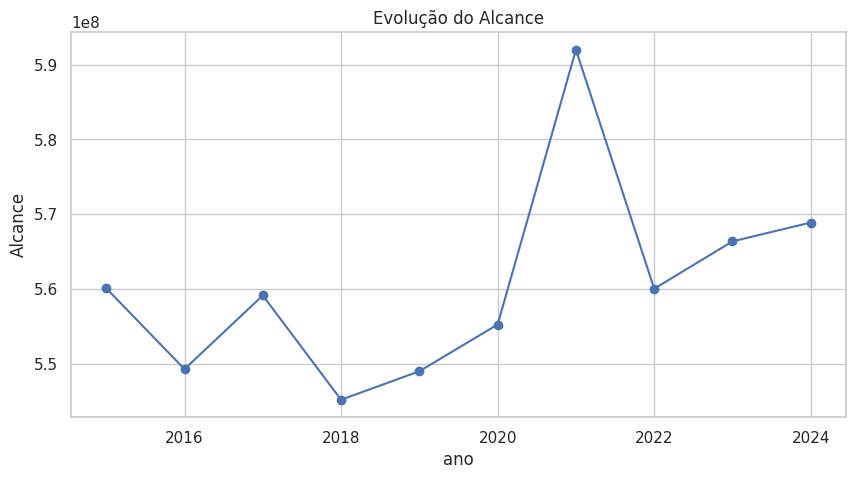

In [17]:
if {'ano','alcance'}.issubset(df.columns):
    df.groupby('ano')['alcance'].sum().plot(marker='o')
    plt.title('Evolução do Alcance')
    plt.ylabel('Alcance')
    plt.show()


# 10. Heatmap de Correlação

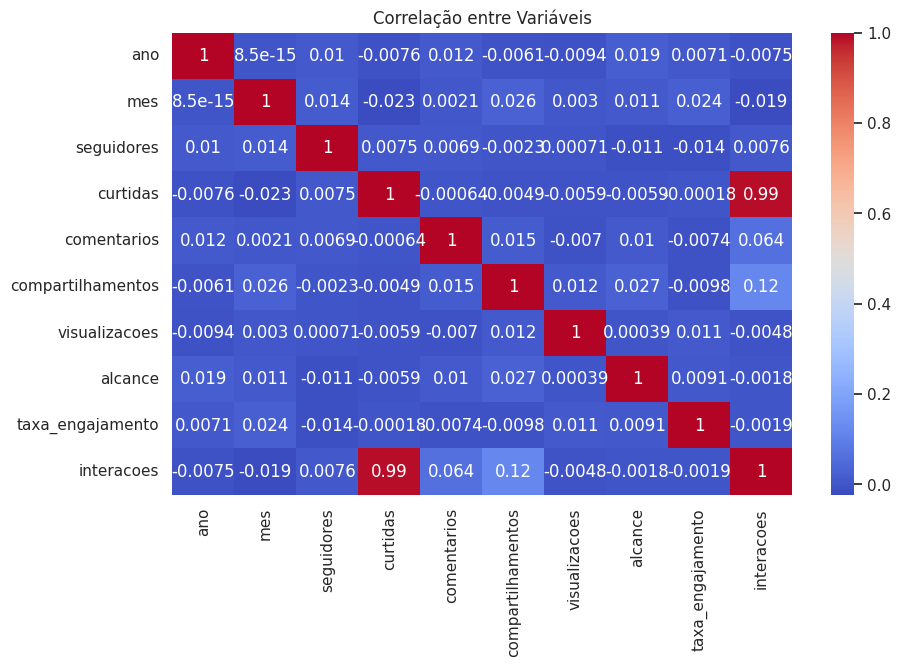

In [18]:
num = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm')
plt.title('Correlação entre Variáveis')
plt.show()


# 11. Insights e Interpretação

Após executar o notebook, registre os principais resultados encontrados:

- Plataforma com maior alcance.
- Plataforma com maior engajamento.
- Tipo de conteúdo com melhor desempenho.
- Tendências temporais observadas.
- Possíveis oportunidades de melhoria.


# 12. Conclusão

A análise permite identificar padrões de desempenho nas redes sociais e apoiar decisões de marketing baseadas em dados.

A partir dos KPIs e visualizações é possível direcionar recursos para as plataformas e conteúdos com melhor retorno.


# 13. Reflexão Final (Data Storytelling)

Se este projeto fosse apresentado a um gestor:

### Principal mensagem
Investir nos canais e formatos com maior engajamento gera melhor retorno.

### Ação recomendada
Priorizar conteúdos e plataformas que demonstraram melhor desempenho nos indicadores analisados.
